# SHAP

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

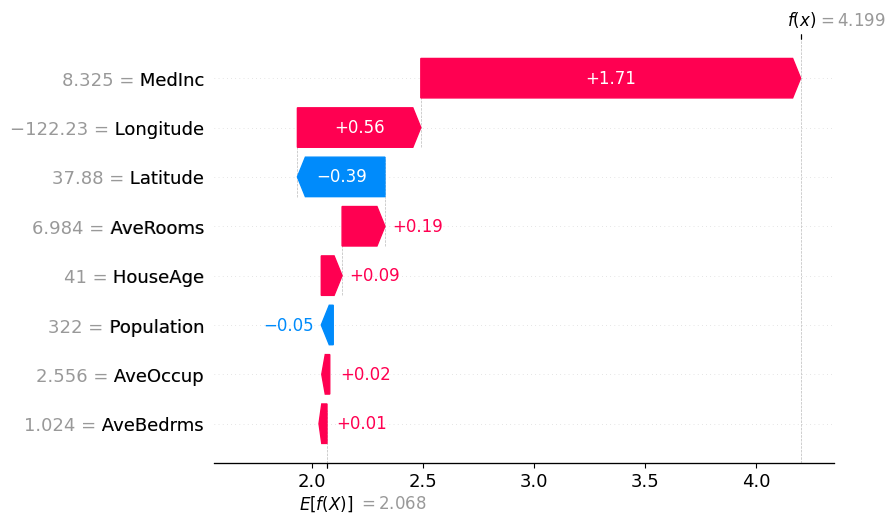

In [1]:
import xgboost
import shap

# train an XGBoost model
X, y = shap.datasets.california()
print(X)
model = xgboost.XGBRegressor().fit(X, y)

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(model)
shap_values = explainer(X)
print(shap_values)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

# Tutorial 


[Lecture 10 - SHAP for text-based data | Explainable AI (XAI) | Force plot | Colab Implementation](https://www.youtube.com/watch?v=700vL2sIla0)

In [2]:
import datasets
from transformers import pipeline
import shap
import numpy as np
import pandas as pd

from datasets import load_dataset

In [3]:
import transformers, torch
print(transformers.__version__, torch.__version__)
!ls

4.51.3 2.7.0
(dev)_Dep_Con_SRL_Demos.ipynb
0-spacy_pipeline.ipynb
1-generate_predictions_langchain-refactored.ipynb
1-predictions_to_df_with_prediction_properties.ipynb
1-test_new_generation_models.ipynb
27_First_RAG_Pipeline-Copy1.ipynb
27_First_RAG_Pipeline.ipynb
33_Hybrid_Retrieval.ipynb
5-models_and_evaluation.ipynb
activation_functions.ipynb
annotators.ipynb
averaging_classification_report.ipynb
basic_knowledge_graph.ipynb
certify_with_llms.ipynb
class_weight_scikit_learn.ipynb
classical_dimensionality_reduction.ipynb
co-occurrenceEx.ipynb
convert_properties_to_1s_and_0s.ipynb
cosine_similarity_scratch.ipynb
csv_to_txt.ipynb
data_acquitision-website.ipynb
data_acquitision-youtube-nfl_sb_lx.ipynb
data_acquitision-youtube.ipynb
embeddings_with_cos_sim.ipynb
entailment.ipynb
entity_resolution-source_target.ipynb
explore_chronicle2050.ipynb
exs_for_paper.ipynb
extract_features_by_variable_type.ipynb
extract_features_get_similarity.ipynb
extract_properties_analysis.ipynb
federal_open_m

## Load Dataset

In [4]:
dataset = datasets.load_dataset("imdb", split="test")
dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [5]:
dataset[0]

{'text': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as 

In [6]:
df = pd.DataFrame(dataset)
df

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
...,...,...
24995,Just got around to seeing Monster Man yesterda...,1
24996,I got this as part of a competition prize. I w...,1
24997,I got Monster Man in a box set of three films ...,1
24998,"Five minutes in, i started to feel how naff th...",1


In [7]:
df = df.loc[:20:, ]
df

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
5,I had high hopes for this one until they chang...,0
6,Isaac Florentine has made some of the best wes...,0
7,"It actually pains me to say it, but this movie...",0
8,"Technically I'am a Van Damme Fan, or I was. th...",0
9,"Honestly awful film, bad editing, awful lighti...",0


In [8]:
classifier = pipeline("sentiment-analysis",
                      model="distilbert-base-uncased-finetuned-sst-2-english",
                      return_all_scores=True)
classifier

Device set to use mps:0
/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/.venv_predictions/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [9]:
text = ["I love Brittany.", "I dislike dogs."]
results = classifier(text)
results

[[{'label': 'NEGATIVE', 'score': 0.00019128333951812238},
  {'label': 'POSITIVE', 'score': 0.9998087286949158}],
 [{'label': 'NEGATIVE', 'score': 0.9973562955856323},
  {'label': 'POSITIVE', 'score': 0.0026436862535774708}]]

In [10]:
classifier(df['text'][0]), df['text'][0]

([[{'label': 'NEGATIVE', 'score': 0.999616265296936},
   {'label': 'POSITIVE', 'score': 0.0003837475669570267}]],
 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions an

In [11]:
df['text'][0], classifier(df['text'][1])


('I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as they hav

In [12]:
classifier(df['text'][2])

[[{'label': 'NEGATIVE', 'score': 0.9997100234031677},
  {'label': 'POSITIVE', 'score': 0.0002899316023103893}]]

In [13]:
short_data = [v[:300] for v in dataset["text"][:20]]
type(short_data), type(short_data[0]), short_data[0]

(list,
 str,
 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, C')

In [14]:
# list(df["text"].values)

In [15]:
type(list(df["text"].values)[0])

str

In [16]:
list(df["text"].values)[0]

'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as they have

In [17]:
# df.loc[:, "text"].values

In [18]:
from sklearn.metrics import accuracy_score

# Predict the sentiment for the short data
predictions = classifier(short_data)

# Convert the predictions to labels
predicted_labels = []
for prediction in predictions:
    predicted_label = max(prediction, key=lambda x: x['score'])['label']
    predicted_labels.append(0 if predicted_label == 'NEGATIVE' else 1)  # Assuming 'NEGATIVE' is 0 and 'POSITIVE' is 1

true_labels = dataset["label"][:20]  # Get the true labels

# Calculate the accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")

print(true_labels)

print(predicted_labels)

Accuracy: 0.75
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [19]:
explainer = shap.Explainer(classifier)
shap_values = explainer(short_data[:2])
shap_values

.values =
array([array([[-0.01516142,  0.01516142],
              [-0.03555838,  0.03555838],
              [-0.14779245,  0.14779245],
              [-0.02400009,  0.02400009],
              [-0.00607884,  0.00607884],
              [-0.00607884,  0.00607884],
              [-0.03027652,  0.03027652],
              [-0.00558934,  0.00558934],
              [-0.00558934,  0.00558934],
              [-0.00369808,  0.00369808],
              [-0.00369808,  0.00369808],
              [-0.01658762,  0.01658762],
              [-0.01658762,  0.01658762],
              [-0.01655639,  0.01655639],
              [-0.01655639,  0.01655639],
              [ 0.0023157 , -0.0023157 ],
              [ 0.00319014, -0.00319014],
              [ 0.00319014, -0.00319014],
              [ 0.00319014, -0.00319014],
              [ 0.00319014, -0.00319014],
              [ 0.00464477, -0.00464477],
              [ 0.00464477, -0.00464477],
              [ 0.00464477, -0.00464477],
              [ 0.004644

In [20]:
shap.plots.text(shap_values[:, :, "POSITIVE"])

# ML Classification-Inference and SHAP

- Datasets:
    1. chronicle2050
    2. sentiment140
    3. financial phrasebank

In [21]:
import os
import sys
import joblib
import warnings

import pandas as pd

from tqdm import tqdm

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from feature_extraction import SpacyFeatureExtraction
from classification_models import SkLearnModelFactory
from explainability import Explainability

In [46]:
%matplotlib inline

import matplotlib.pyplot as plt

In [22]:
warnings.filterwarnings('ignore')

## Load Dataset(s)

In [23]:
base_path = DataProcessing.load_base_data_path(notebook_dir)

### Load chronicle2050

- CODE: [chronicle2050](https://github.com/regevson/chronicle2050/tree/master/dataset): 6,800 sentences from several datasets (Longbets, Horizons, New York Times, and ChatGPT).
- PAPER: [Future Timelines: Extraction and Visualization of Future-Related](https://dl.acm.org/doi/10.1145/3616855.3635693)

- Mappings:
    - 0s: Non-Future-Related
    - 1s: Future-Related

In [24]:
df_name = 'chronicle2050'

In [25]:
if df_name == 'chronicle2050':
    chronicle2050_path = os.path.join(base_path, 'chronicle2050', 'data.csv')
    df = DataProcessing.load_from_file(chronicle2050_path, sep=',')

elif df_name == 'sentiment140':
    sentiment140_path = os.path.join(base_path, 'sentiment140', 'data.csv')
    df = pd.read_csv(sentiment140_path, encoding = "ISO-8859-1", header=None)
    # sentiment140_df = DataProcessing.load_from_file(sentiment140_path, sep=',')
    df.columns = [
        "target",      # Sentiment label: 0 = negative, 4 = positive
        "id",          # Tweet ID
        "date",        # Date of the tweet
        "flag",        # Query (unused, often 'NO_QUERY')
        "user",        # Username of the tweet author
        "sentence"         # The tweet content
    ]
df

,index,sentence,label
0,0,"By January 1st, 2037, Tesla will have been the...",1
1,1,An annual average temperature anomaly value ab...,1
2,2,Private Nonfarm business productivity growth w...,1
3,3,No Republican will be President of the USA bef...,1
4,4,The market capitalization of Berkshire Hathawa...,1
...,...,...,...
6397,2540,Many major technology players are [TeleNav Inc...,0
6398,2541,"WaterIQ Technologies, the leader in next-gener...",0
6399,2542,The Business Research Company's 'Clean Coal Te...,0
6400,2543,'Prophecy Market Insights offers a 20% discoun...,0


## Embed Sentences

In [26]:
spacy_fe = SpacyFeatureExtraction(df, 'sentence')
# spacy_fe = SpacyFeatureExtraction(sentiment140_df, 'sentence')
embeddings_spacy_fe_df = spacy_fe.sentence_embeddings_extraction()
embeddings_spacy_fe_df.rename(columns={'sentence Embedding': 'sentence embedding'}, inplace=True)
embeddings_spacy_fe_df

100%|██████████| 6402/6402 [00:26<00:00, 237.98it/s]


,index,sentence,label,sentence embedding
0,0,"By January 1st, 2037, Tesla will have been the...",1,"[-0.046937417, 0.18488835, -0.019333577, -0.09..."
1,1,An annual average temperature anomaly value ab...,1,"[-0.080327354, 0.18459626, 0.0097009195, -0.01..."
2,2,Private Nonfarm business productivity growth w...,1,"[-0.09731141, 0.27078336, 0.020201702, -0.0160..."
3,3,No Republican will be President of the USA bef...,1,"[0.029054716, 0.19021763, 0.065829575, -0.1418..."
4,4,The market capitalization of Berkshire Hathawa...,1,"[-0.058103725, 0.20959128, 0.09174133, -0.0162..."
...,...,...,...,...
6397,2540,Many major technology players are [TeleNav Inc...,0,"[-0.070845485, 0.28657782, 0.01468689, -0.1156..."
6398,2541,"WaterIQ Technologies, the leader in next-gener...",0,"[-0.11760226, 0.16071157, -0.038852997, -0.098..."
6399,2542,The Business Research Company's 'Clean Coal Te...,0,"[-0.12741901, 0.2028387, 0.023308, -0.05081283..."
6400,2543,'Prophecy Market Insights offers a 20% discoun...,0,"[-0.109398074, 0.19629641, -0.07043434, 0.0243..."


## Load Models

In [27]:
ml_model_checkpoints = {}

model_checkpoint_path = os.path.join(base_path, 'classification_results/combined-full_synthetic-v1_2026-03-04/seed26/model_checkpoints')
model_checkpoint_files = os.listdir(model_checkpoint_path)

for model_checkpoint_filename in model_checkpoint_files:
    specific_model_checkpoint_path = os.path.join(model_checkpoint_path, model_checkpoint_filename)
    # print(specific_model_checkpoint_path)
    model_name = specific_model_checkpoint_path[218:-4]
    # print(model_name)
    if "Sentence Label" in model_name:
        print(model_name)
        ml_model_checkpoint = joblib.load(specific_model_checkpoint_path)
        ml_model_checkpoints[model_name] = ml_model_checkpoint

logistic_regression-Sentence Label
sgd_classifier-Sentence Label
support_vector_machine_classifier-Sentence Label
random_forest_classifier-Sentence Label
decision_tree_classifier-Sentence Label
gradient_boosting_classifier-Sentence Label
ridge_classifier-Sentence Label
perceptron-Sentence Label
x_gradient_boosting_classifier-Sentence Label


In [28]:
ml_model_checkpoints

{'logistic_regression-Sentence Label': <classification_models.SkLearnLogisticRegression at 0x17ff99210>,
 'sgd_classifier-Sentence Label': <classification_models.SkLearnSGDClassifier at 0x17ff9b910>,
 'support_vector_machine_classifier-Sentence Label': <classification_models.SkLearnSVC at 0x17ff995d0>,
 'random_forest_classifier-Sentence Label': <classification_models.SkLearnRandomForestClassifier at 0x17ff63790>,
 'decision_tree_classifier-Sentence Label': <classification_models.SkLearnDecisionTreeClassifier at 0x17fdfff90>,
 'gradient_boosting_classifier-Sentence Label': <classification_models.SkLearnGradientBoostingClassifier at 0x163afd310>,
 'ridge_classifier-Sentence Label': <classification_models.SkLearnRidgeClassifier at 0x17ff32b90>,
 'perceptron-Sentence Label': <classification_models.SkLearnPerceptronModel at 0x17ff32510>,
 'x_gradient_boosting_classifier-Sentence Label': <classification_models.CustomXGBClassifier at 0x17fefa110>}

## Inference

Predict for Logistic Regression
	✓ SHAP explanation for Logistic Regression


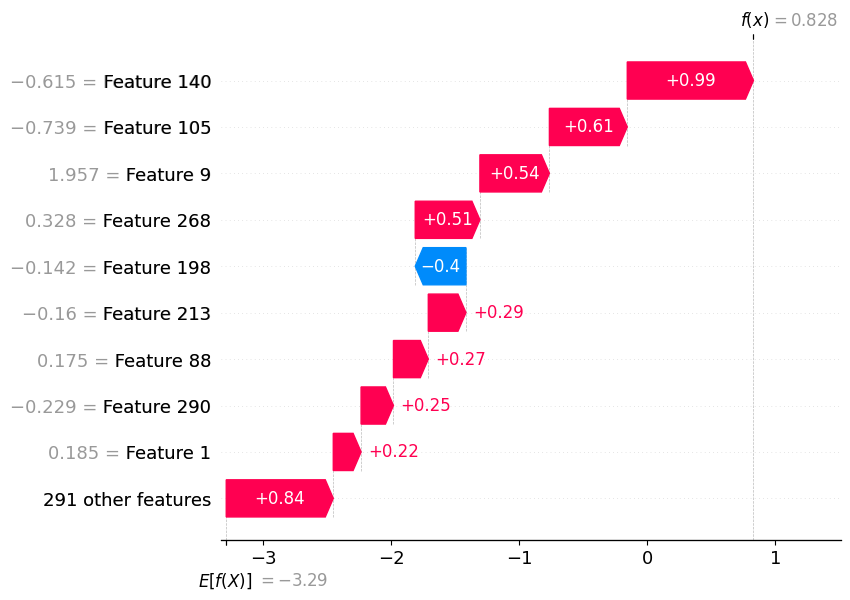

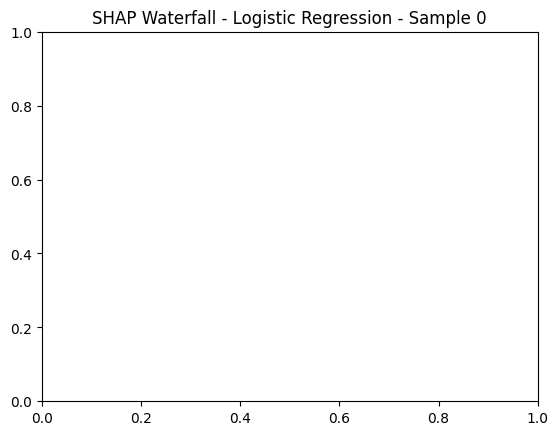

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...
	  Explaining: 'By January 1st, 2037, Tesla will have been the first company...'


100%|██████████| 1/1 [00:00<00:00, 139.62it/s]

	  LIME Text Explanation:
	  Original sentence: By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.
	  Prediction probabilities:
	    Non-Prediction: 0.304
	    Prediction: 0.696
	  Word importance (+ = toward Prediction, - = toward Non-Prediction):
	    'January': +0.039
	    '1st': +0.039
	    '2037': +0.039
	    'Tesla': +0.039
	    'will': +0.039
	    'been': +0.039
	    'first': +0.039
	    'company': +0.039
	✓ LIME explanation displayed and saved to HTML

Predict for SDG Classifier
	✓ SHAP explanation for SDG Classifier


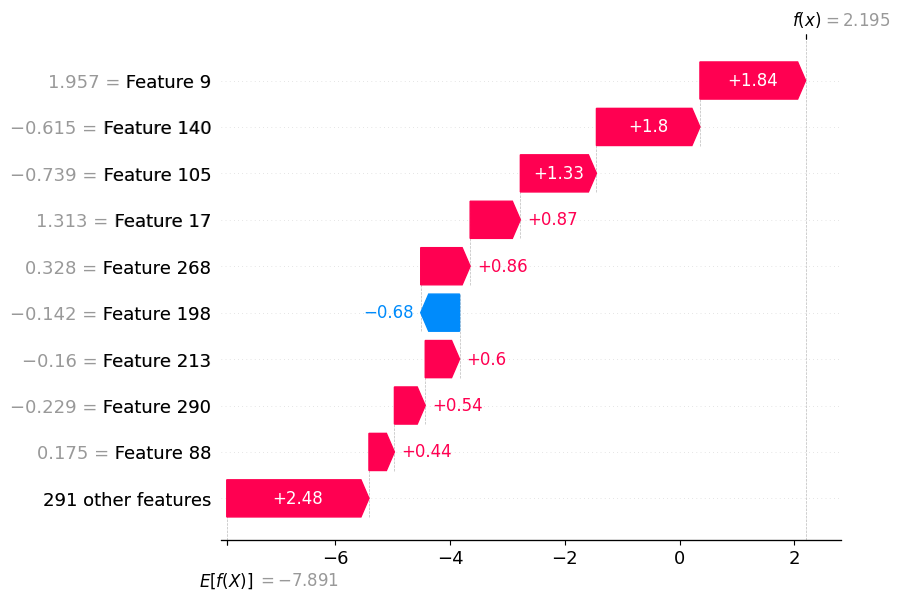

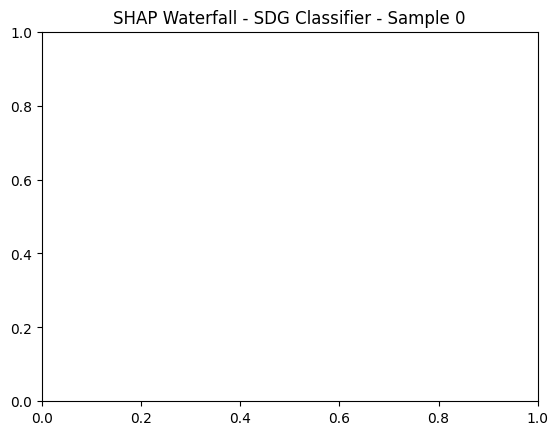

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...
	  Explaining: 'By January 1st, 2037, Tesla will have been the first company...'


100%|██████████| 1/1 [00:00<00:00, 110.37it/s]


	  LIME Text Explanation:
	  Original sentence: By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.
	  Prediction probabilities:
	    Non-Prediction: 0.100
	    Prediction: 0.900
	  Word importance (+ = toward Prediction, - = toward Non-Prediction):
	    '2037': +0.115
	    'January': +0.072
	    'will': +0.072
	    'are': +0.072
	    'SAE': +0.072
	    'United': +0.072
	    'better': +0.072
	    'usable': +0.072
	✓ LIME explanation displayed and saved to HTML

Predict for Support Vector Machine
	⚠️ Skipping SHAP
Predict for Random Forest
	✓ SHAP explanation for Random Forest


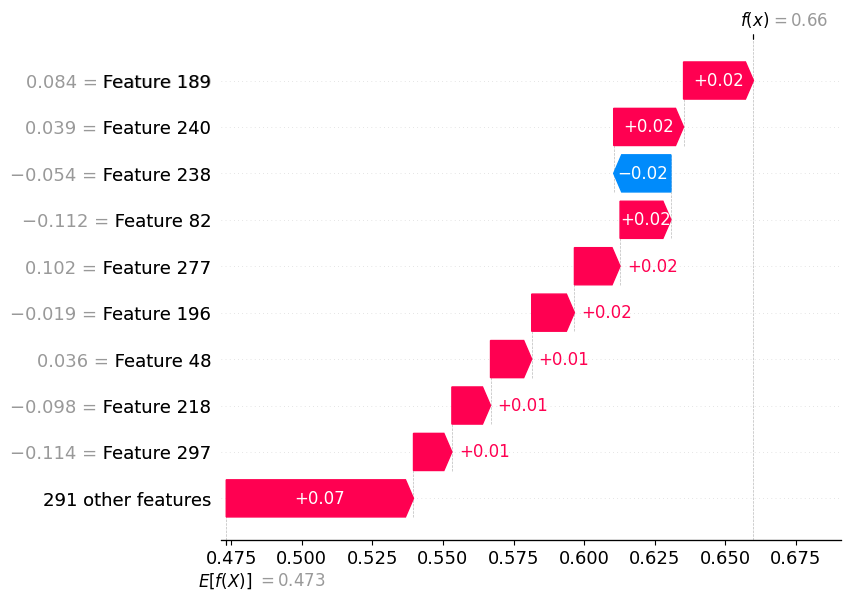

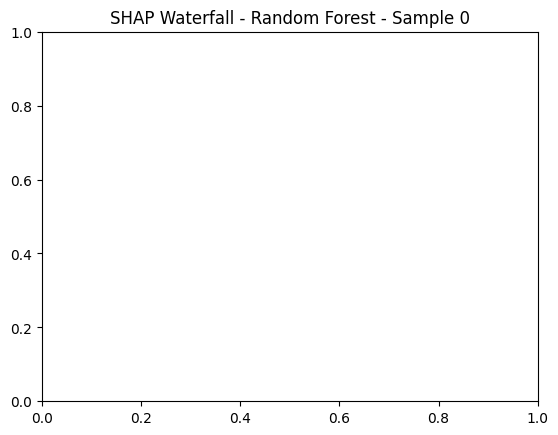

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...
	  Explaining: 'By January 1st, 2037, Tesla will have been the first company...'


100%|██████████| 1/1 [00:00<00:00, 116.70it/s]

	  LIME Text Explanation:
	  Original sentence: By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.
	  Prediction probabilities:
	    Non-Prediction: 0.340
	    Prediction: 0.660
	  Word importance (+ = toward Prediction, - = toward Non-Prediction):
	    'Tesla': -0.010
	    'been': -0.010
	    'first': -0.010
	    'with': -0.010
	    '1': -0.010
	    'vehicles': -0.010
	    'that': -0.010
	    'Level': -0.010
	✓ LIME explanation displayed and saved to HTML

Predict for Decision Tree
	✓ SHAP explanation for Decision Tree


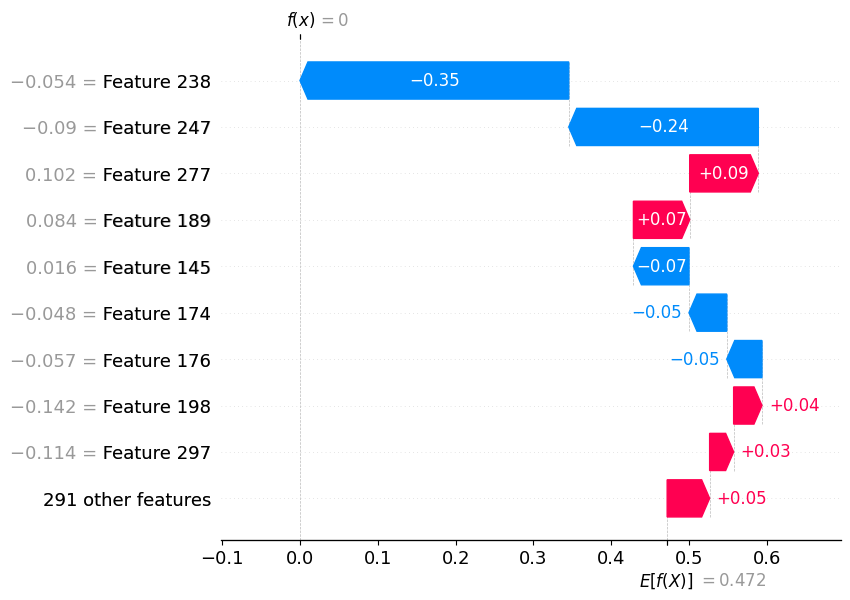

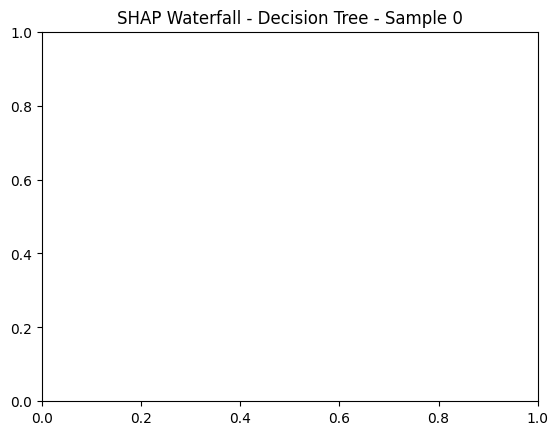

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...
	  Explaining: 'By January 1st, 2037, Tesla will have been the first company...'


100%|██████████| 1/1 [00:00<00:00, 143.82it/s]

	  LIME Text Explanation:
	  Original sentence: By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.
	  Prediction probabilities:
	    Non-Prediction: 1.000
	    Prediction: 0.000
	  Word importance (+ = toward Prediction, - = toward Non-Prediction):
	    'By': 0.000
	    'January': 0.000
	    '1st': 0.000
	    '2037': 0.000
	    'Tesla': 0.000
	    'will': 0.000
	    'have': 0.000
	    'been': 0.000
	✓ LIME explanation displayed and saved to HTML

Predict for Gradient Boosting Machine
	⚠️ Skipping SHAP
Predict for Ridge Classifier
	⚠️ Skipping Ridge Classifier (no predict_proba)
Predict for Perceptron
	⚠️ Skipping Perceptron (no predict_proba)
Predict for X Gradient Boosting Machine
	⚠️ Skipping SHAP


In [54]:
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from feature_extraction import SpacyFeatureExtraction

ml_models_with_predictions = {}
sentence_embeddings = embeddings_spacy_fe_df['sentence embedding'].to_list()
sentences = embeddings_spacy_fe_df['sentence'].to_list()  # ← ADD: Get original text
ml_models_with_predictions[df_name] = {}

for model_file_name, ml_model in ml_model_checkpoints.items():
    model_name = ml_model.get_model_name()
    print(f"Predict for {model_name}")
    classifier = ml_model.classifer
    
    # Skip models that don't have predict_proba
    if not hasattr(classifier, 'predict_proba'):
        print(f"\t⚠️ Skipping {model_name} (no predict_proba)")
        continue
    
    shap_values = None
    
    if model_name in ['Logistic Regression', 'SDG Classifier']:
        explainer = shap.LinearExplainer(classifier, np.zeros((1, len(sentence_embeddings[0]))))
        shap_values = explainer(np.array(sentence_embeddings))
        print(f"\t✓ SHAP explanation for {model_name}")
        
    elif model_name in ['Random Forest', 'Decision Tree']:
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer(np.array(sentence_embeddings))
        print(f"\t✓ SHAP explanation for {model_name}")
    else:
        print(f"\t⚠️ Skipping SHAP")
        continue
    
    # SHAP plots (your existing code)
    if shap_values is not None:
        try:
            if len(shap_values.shape) == 3:
                shap_values_to_plot = shap_values[0, :, 1]
            else:
                shap_values_to_plot = shap_values[0, :]
            
            plt.figure()
            shap.plots.waterfall(shap_values_to_plot)
            plt.title(f'SHAP Waterfall - {model_name} - Sample 0')
            plt.show()
            print(f"\t✓ SHAP waterfall displayed")
            
        except Exception as e:
            print(f"\t❌ SHAP plot failed: {e}")
    
    # ADD: LIME text explanation
    try:
        print(f"\t→ Generating LIME text explanation...")
        
        def predict_proba_from_text(texts):
            """Convert text to embeddings then predict"""
            embeddings = []
            for text in texts:
                temp_df = pd.DataFrame({'sentence': [text]})
                spacy_fe = SpacyFeatureExtraction(temp_df, 'sentence')
                embedded_df = spacy_fe.sentence_embeddings_extraction(attach_to_df=True)
                embeddings.append(embedded_df.iloc[0]['sentence Embedding'])
            return classifier.predict_proba(np.array(embeddings))
        
        # LIME explainer
        lime_explainer = LimeTextExplainer(class_names=['Non-Prediction', 'Prediction'])

        # Explain first sentence
        first_sentence = sentences[0]
        print(f"\t  Explaining: '{first_sentence[:60]}...'")

        lime_exp = lime_explainer.explain_instance(
            first_sentence,
            predict_proba_from_text,
            num_features=8,
            num_samples=3
        )

        # SIMPLE text display (no fancy notebook display needed)
        print(f"\t  LIME Text Explanation:")
        print(f"\t  Original sentence: {first_sentence}")
        print(f"\t  Prediction probabilities:")

        # Get prediction probabilities
        probs = lime_exp.predict_proba
        print(f"\t    Non-Prediction: {probs[0]:.3f}")
        print(f"\t    Prediction: {probs[1]:.3f}")

        # Show word importance with simple formatting
        print(f"\t  Word importance (+ = toward Prediction, - = toward Non-Prediction):")
        for word, weight in lime_exp.as_list():
            symbol = "+" if weight > 0 else ""
            print(f"\t    '{word}': {symbol}{weight:.3f}")

        # Optional: Save as HTML for later viewing
        save_path = os.path.join(base_path, 'classification_results/combined-full_synthetic-v1_2026-03-04/seed26', f'lime_text_{model_file_name}_sample0.html')
        lime_exp.save_to_file(save_path)

        print(f"\t✓ LIME explanation displayed and saved to HTML")
                
    except Exception as e:
        print(f"\t❌ LIME explanation failed: {e}")
    
    print()

Predict for Logistic Regression
	✓ SHAP explanation for Logistic Regression


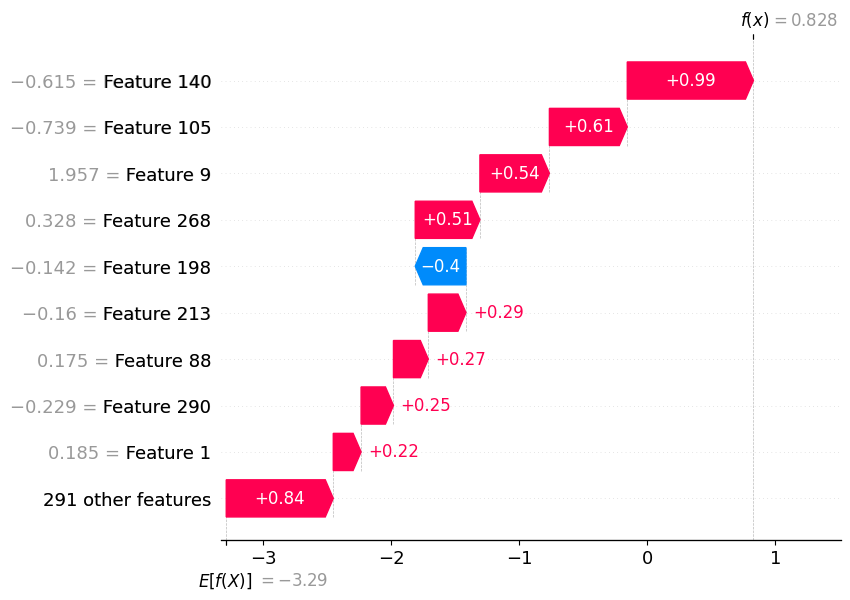

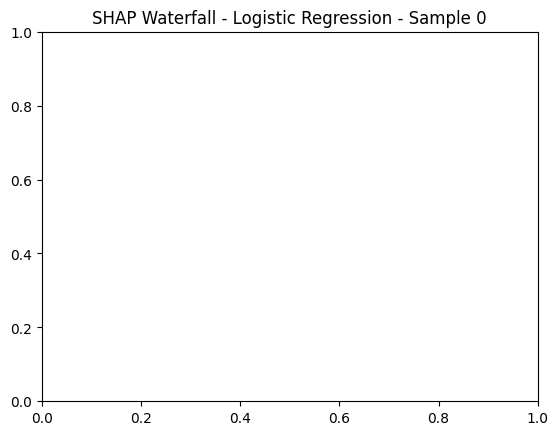

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...


100%|██████████| 1/1 [00:00<00:00, 135.24it/s]

	    Non-Prediction: 0.304, Prediction: 0.696
	✓ LIME explanation collected

Predict for SDG Classifier
	✓ SHAP explanation for SDG Classifier


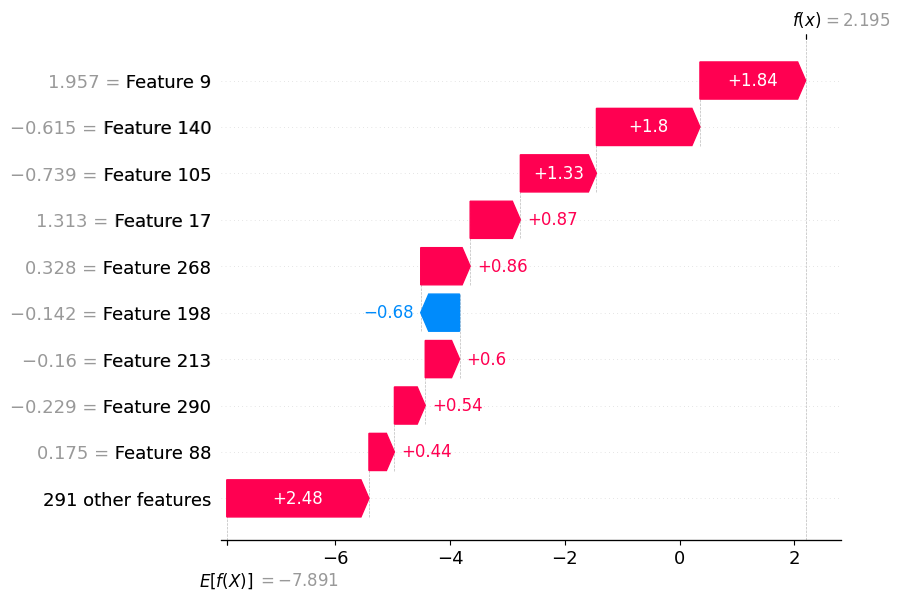

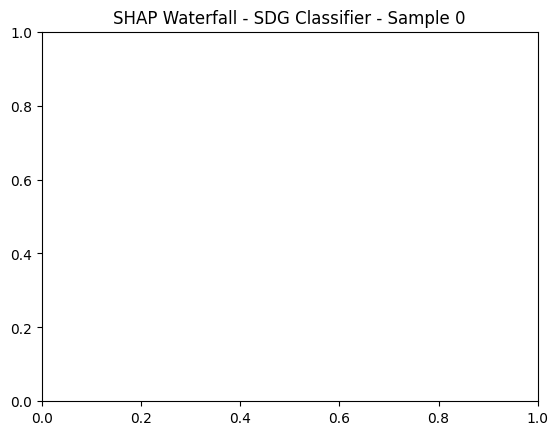

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...


100%|██████████| 1/1 [00:00<00:00, 179.54it/s]


	    Non-Prediction: 0.100, Prediction: 0.900
	✓ LIME explanation collected

Predict for Support Vector Machine
	⚠️ Skipping SHAP
Predict for Random Forest
	✓ SHAP explanation for Random Forest


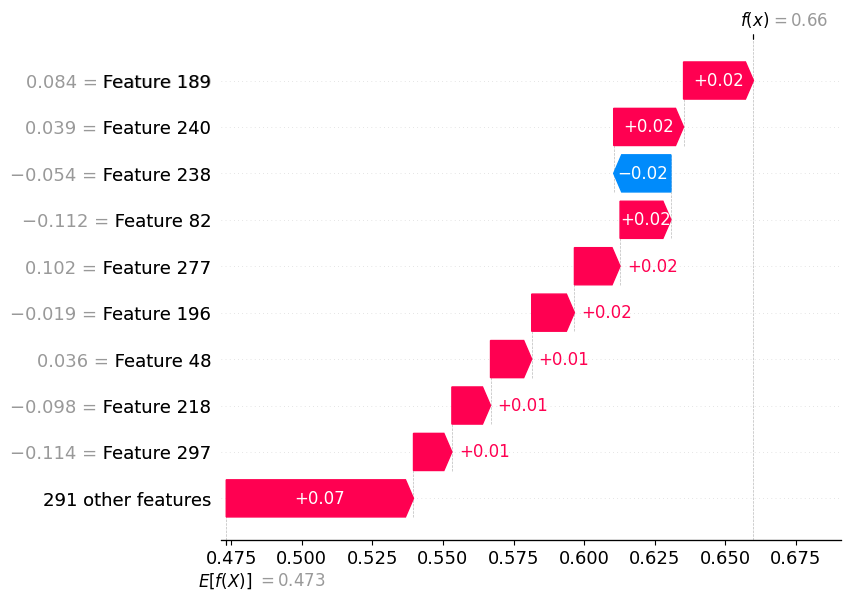

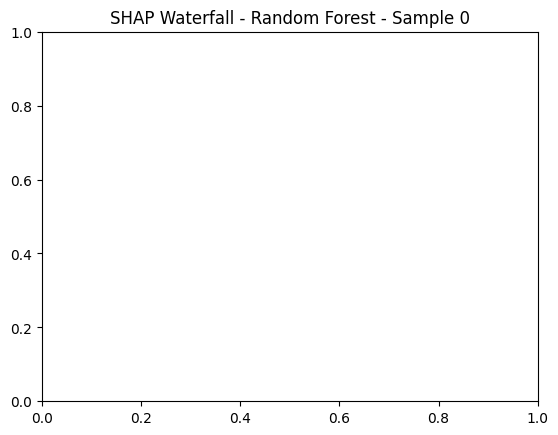

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...


100%|██████████| 1/1 [00:00<00:00, 164.12it/s]


	    Non-Prediction: 0.340, Prediction: 0.660
	✓ LIME explanation collected

Predict for Decision Tree
	✓ SHAP explanation for Decision Tree


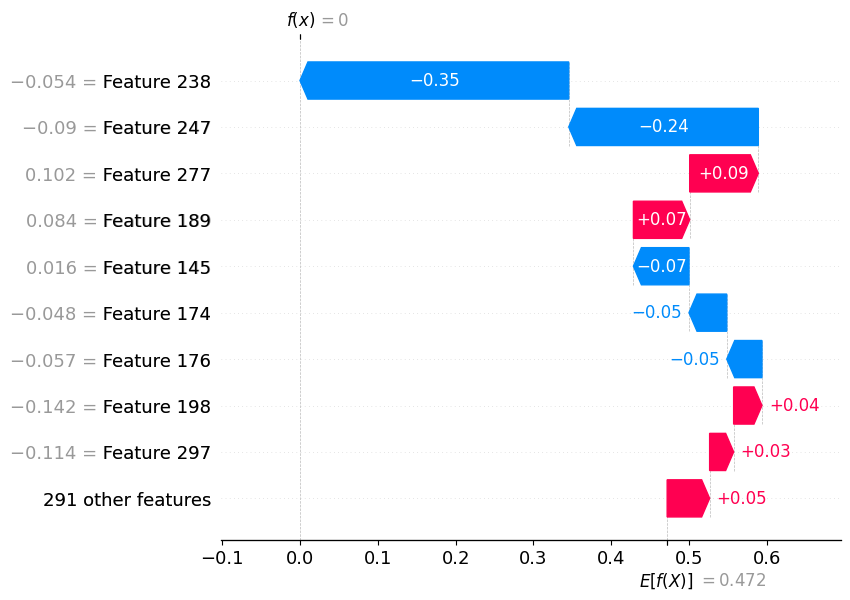

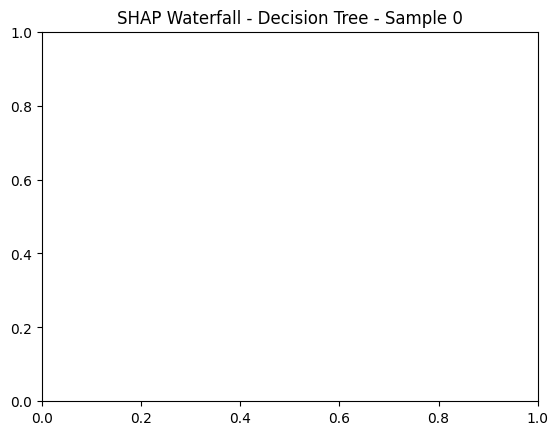

	✓ SHAP waterfall displayed
	→ Generating LIME text explanation...


100%|██████████| 1/1 [00:00<00:00, 133.50it/s]

	    Non-Prediction: 1.000, Prediction: 0.000
	✓ LIME explanation collected

Predict for Gradient Boosting Machine
	⚠️ Skipping SHAP
Predict for Ridge Classifier
	⚠️ Skipping Ridge Classifier (no predict_proba)
Predict for Perceptron
	⚠️ Skipping Perceptron (no predict_proba)
Predict for X Gradient Boosting Machine
	⚠️ Skipping SHAP

CREATING LIME MODEL COMPARISON
✓ Comparison HTML saved: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/classification_results/combined-full_synthetic-v1_2026-03-04/seed26/lime_comparison_all_models.html
✓ Open the HTML file to see all models' explanations side-by-side!


In [56]:
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from feature_extraction import SpacyFeatureExtraction

ml_models_with_predictions = {}
sentence_embeddings = embeddings_spacy_fe_df['sentence embedding'].to_list()
sentences = embeddings_spacy_fe_df['sentence'].to_list()
ml_models_with_predictions[df_name] = {}

# Store all LIME explanations for comparison
all_lime_explanations = {}
first_sentence = sentences[0]

for model_file_name, ml_model in ml_model_checkpoints.items():
    model_name = ml_model.get_model_name()
    print(f"Predict for {model_name}")
    classifier = ml_model.classifer
    
    # Skip models that don't have predict_proba
    if not hasattr(classifier, 'predict_proba'):
        print(f"\t⚠️ Skipping {model_name} (no predict_proba)")
        continue
    
    # [Your existing SHAP code here - unchanged]
    shap_values = None
    if model_name in ['Logistic Regression', 'SDG Classifier']:
        explainer = shap.LinearExplainer(classifier, np.zeros((1, len(sentence_embeddings[0]))))
        shap_values = explainer(np.array(sentence_embeddings))
        print(f"\t✓ SHAP explanation for {model_name}")
        
    elif model_name in ['Random Forest', 'Decision Tree']:
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer(np.array(sentence_embeddings))
        print(f"\t✓ SHAP explanation for {model_name}")
    else:
        print(f"\t⚠️ Skipping SHAP")
        continue
    
    # SHAP plots
    if shap_values is not None:
        try:
            if len(shap_values.shape) == 3:
                shap_values_to_plot = shap_values[0, :, 1]
            else:
                shap_values_to_plot = shap_values[0, :]
            
            plt.figure()
            shap.plots.waterfall(shap_values_to_plot)
            plt.title(f'SHAP Waterfall - {model_name} - Sample 0')
            plt.show()
            print(f"\t✓ SHAP waterfall displayed")
        except Exception as e:
            print(f"\t❌ SHAP plot failed: {e}")
    
    # LIME explanation - COLLECT for comparison
    try:
        print(f"\t→ Generating LIME text explanation...")
        
        def predict_proba_from_text(texts):
            embeddings = []
            for text in texts:
                temp_df = pd.DataFrame({'sentence': [text]})
                spacy_fe = SpacyFeatureExtraction(temp_df, 'sentence')
                embedded_df = spacy_fe.sentence_embeddings_extraction(attach_to_df=True)
                embeddings.append(embedded_df.iloc[0]['sentence Embedding'])
            return classifier.predict_proba(np.array(embeddings))
        
        lime_explainer = LimeTextExplainer(class_names=['Non-Prediction', 'Prediction'])
        lime_exp = lime_explainer.explain_instance(
            first_sentence,
            predict_proba_from_text,
            num_features=8,
            num_samples=7
        )
        
        # Store explanation for comparison
        all_lime_explanations[model_name] = lime_exp
        
        probs = lime_exp.predict_proba
        print(f"\t    Non-Prediction: {probs[0]:.3f}, Prediction: {probs[1]:.3f}")
        print(f"\t✓ LIME explanation collected")
        
    except Exception as e:
        print(f"\t❌ LIME explanation failed: {e}")
    
    print()

# CREATE COMPARISON HTML after collecting all explanations
print("\n" + "="*60)
print("CREATING LIME MODEL COMPARISON")
print("="*60)

comparison_html = f"""
<html>
<head>
    <title>LIME Model Comparison</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        .model-section {{ border: 1px solid #ccc; margin: 20px 0; padding: 15px; }}
        .model-title {{ font-size: 18px; font-weight: bold; color: #333; }}
        .sentence {{ background-color: #f5f5f5; padding: 10px; margin: 10px 0; }}
        .probability {{ margin: 10px 0; }}
    </style>
</head>
<body>
    <h1>LIME Explanations Comparison</h1>
    <div class="sentence">
        <strong>Sentence:</strong> {first_sentence}
    </div>
"""

for model_name, lime_exp in all_lime_explanations.items():
    probs = lime_exp.predict_proba
    comparison_html += f"""
    <div class="model-section">
        <div class="model-title">{model_name}</div>
        <div class="probability">
            <strong>Probabilities:</strong> 
            Non-Prediction: {probs[0]:.3f} | Prediction: {probs[1]:.3f}
        </div>
        {lime_exp.as_html()}
    </div>
    """

comparison_html += """
</body>
</html>
"""

# Save comparison HTML
comparison_path = os.path.join(base_path, 'classification_results/combined-full_synthetic-v1_2026-03-04/seed26', 'lime_comparison_all_models.html')
with open(comparison_path, 'w') as f:
    f.write(comparison_html)

print(f"✓ Comparison HTML saved: {comparison_path}")
print("✓ Open the HTML file to see all models' explanations side-by-side!")

### Align Dataset Sentences with Predicted Sentence Label from Models

In [ ]:
results_df = embeddings_spacy_fe_df.copy()
for key, value in ml_models_with_predictions[df_name].items():
    results_df[key] = value.to_list()
results_df

## Save Output

In [ ]:
# save_chronicle2050_results_path = os.path.join(base_path, 'inference/chronicle2050_results')
# save_sentiment140_results_path = os.path.join(base_path, 'inference/sentiment140_results')

In [ ]:
# DataProcessing.save_to_file(results_df, save_chronicle2050_results_path, 'chronicle2050_results', '.csv')
# DataProcessing.save_to_file(results_df, save_sentiment140_results_path, 'sentiment140_results', '.csv')

### Check if properly saved

In [ ]:
# load_chronicle2050_results_path = os.path.join(base_path, save_chronicle2050_results_path, 'chronicle2050_results-v5.csv')
# load_chronicle2050_results_df = DataProcessing.load_from_file(load_chronicle2050_results_path, sep=',')
# load_chronicle2050_results_df